In [38]:
from camel_tools.disambig.bert import BERTUnfactoredDisambiguator
from camel_tools.morphology.analyzer import Analyzer
from camel_tools.morphology.database import MorphologyDB
from camel_tools.tokenizers.word import simple_word_tokenize
# import diac form camel_tools
from camel_tools.utils.charsets import AR_DIAC_CHARSET


In [39]:

# db = MorphologyDB("/Users/nour.rabih/Desktop/arwi/camel_morph_msa_v1.0.db", "a")
db = MorphologyDB("/Users/nour.rabih/Desktop/arwi/calima-msa-s31.db", "a")

# Initialize the analyzer
analyzer = Analyzer(db, 'NONE', cache_size=100000)


word ='المُبالغات'
alls = analyzer.analyze(word) 

In [40]:
len(alls)

16

In [41]:
alls

[{'diac': 'المُبالَغات',
  'lex': 'مُبالَغَة',
  'caphi': '2_a_l_m_u_b_aa_l_a_gh_aa_t',
  'gloss': 'the+exaggeration+[fem.pl.]',
  'bw': 'ال/DET+مُبالَغ/NOUN+ات/NSUFF_FEM_PL',
  'pos': 'noun',
  'catib6': 'NOM',
  'ud': 'NOUN',
  'root': 'ب.ل.غ',
  'pattern': 'المُ1ا2َ3ات',
  'prc3': '0',
  'prc2': '0',
  'prc1': '0',
  'prc0': 'Al_det',
  'per': 'na',
  'asp': 'na',
  'vox': 'na',
  'mod': 'na',
  'form_gen': 'f',
  'gen': 'f',
  'form_num': 'p',
  'num': 'p',
  'stt': 'd',
  'cas': 'u',
  'enc0': '0',
  'rat': 'i',
  'source': 'lex',
  'd1seg': 'المُبالَغات',
  'd2seg': 'المُبالَغات',
  'd3seg': 'ال+_مُبالَغات',
  'atbseg': 'المُبالَغات',
  'd1tok': 'المُبالَغات',
  'd2tok': 'المُبالَغات',
  'd3tok': 'ال+_مُبالَغات',
  'atbtok': 'المُبالَغات',
  'bwtok': 'ال+_مُبالَغ_+ات',
  'pos_logprob': -0.4344233,
  'lex_logprob': -5.099521,
  'pos_lex_logprob': -5.099521,
  'stem': 'مُبالَغ',
  'stemgloss': 'exaggeration',
  'stemcat': 'NapAt'},
 {'diac': 'المُبالَغات',
  'lex': 'مُبالَغَة',
  '

## Diacritic Labeling
Label each analysis YES if the diacritic(s) in the input word match the same consonant positions in the analysis `diac` field.

In [42]:

# unfreeze AR_DIAC_CHARSET
AR_DIAC_CHARSET = set(AR_DIAC_CHARSET)

In [43]:
# DIAC_SET = set('ًٌٍَُِّْ')

def get_diacs_per_consonant(word):
    result = {}
    consonant_idx = 0
    i = 0
    while i < len(word):
        ch = word[i]
        if ch not in AR_DIAC_CHARSET:
            diacs = []
            j = i + 1
            while j < len(word) and word[j] in AR_DIAC_CHARSET:
                diacs.append(word[j])
                j += 1
            if diacs:
                result[consonant_idx] = ''.join(diacs)
            consonant_idx += 1
            i = j
        else:
            i += 1
    return result

def diac_matches(input_word, analysis_diac):
    # Reject analyses with different base consonants
    strip = lambda w: ''.join(c for c in w if c not in AR_DIAC_CHARSET)
    if strip(input_word) != strip(analysis_diac):
        return False
    input_diacs   = get_diacs_per_consonant(input_word)
    analysis_diacs = get_diacs_per_consonant(analysis_diac)
    for pos, diac in input_diacs.items():
        analysis_at_pos = analysis_diacs.get(pos, '')
        if not all(c in analysis_at_pos for c in diac):
            return False
    return True


input_diacs = get_diacs_per_consonant(word)
print(f"Input word: {word}")
print(f"Diacritics at consonant positions: {input_diacs}")
print()

labels = [1 if diac_matches(word, a['diac']) else 0 for a in alls]

for a, label in zip(alls, labels):
    mark = "YES" if label else "NO "
    print(f"{mark}  {a['diac']:15s}  pos={a['pos']:10s}  pattern={a.get('pattern','—')}")

Input word: المُبالغات
Diacritics at consonant positions: {2: 'ُ'}

YES  المُبالَغات      pos=noun        pattern=المُ1ا2َ3ات
YES  المُبالَغات      pos=noun        pattern=المُ1ا2َ3ات
YES  المُبالَغاتُ     pos=noun        pattern=المُ1ا2َ3اتُ
YES  المُبالَغاتُ     pos=noun        pattern=المُ1ا2َ3اتُ
YES  المُبالَغاتِ     pos=noun        pattern=المُ1ا2َ3اتِ
YES  المُبالَغاتِ     pos=noun        pattern=المُ1ا2َ3اتِ
YES  المُبالَغاتِ     pos=noun        pattern=المُ1ا2َ3اتِ
YES  المُبالَغاتِ     pos=noun        pattern=المُ1ا2َ3اتِ
YES  المُبالِغات      pos=adj         pattern=المُ1ا2ِ3ات
YES  المُبالِغات      pos=adj         pattern=المُ1ا2ِ3ات
YES  المُبالِغاتُ     pos=adj         pattern=المُ1ا2ِ3اتُ
YES  المُبالِغاتُ     pos=adj         pattern=المُ1ا2ِ3اتُ
YES  المُبالِغاتِ     pos=adj         pattern=المُ1ا2ِ3اتِ
YES  المُبالِغاتِ     pos=adj         pattern=المُ1ا2ِ3اتِ
YES  المُبالِغاتِ     pos=adj         pattern=المُ1ا2ِ3اتِ
YES  المُبالِغاتِ     pos=adj         pattern=المُ1

In [44]:
from collections import defaultdict

pos_diacs = defaultdict(set)

for a in alls:
    diac_str = a['diac']
    n_consonants = sum(1 for ch in diac_str if ch not in AR_DIAC_CHARSET)
    diacs_present = get_diacs_per_consonant(diac_str)

    for pos in range(n_consonants):
        if pos in diacs_present:
            pos_diacs[pos].add(diacs_present[pos])
        else:
            pos_diacs[pos].add('∅')

print(f"{'Position':<10} {'# distinct':<14} values")
print("-" * 55)
for pos in sorted(pos_diacs):
    diacs = pos_diacs[pos]
    print(f"{pos:<10} {len(diacs):<14} {diacs}")

Position   # distinct     values
-------------------------------------------------------
0          1              {'∅'}
1          1              {'∅'}
2          1              {'ُ'}
3          1              {'∅'}
4          1              {'∅'}
5          2              {'َ', 'ِ'}
6          1              {'∅'}
7          1              {'∅'}
8          3              {'∅', 'ِ', 'ُ'}


## Decision Tree
Train a decision tree on morphological features to extract what the diacritic constrains.

In [45]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, _tree, export_text

FEATURES = ['pos', 'vox', 'mod', 'gen', 'asp', 'num', 'stt', 'cas', 'rat',
            'prc0', 'prc1', 'prc2', 'prc3', 'per', 'enc0',  'pattern']

# 'stemcat',
#pattern

df = pd.DataFrame(alls)
df['label'] = labels

X = pd.get_dummies(df[FEATURES].fillna('NA').astype(str))
X = X[[c for c in X.columns if not c.endswith('_na') and not c.endswith('_NA')
                             and not c.endswith('_backoff')]]
y = df['label']

pos_cols   = [c for c in X.columns if c.startswith('pos_')]
other_cols = [c for c in X.columns if not c.startswith('pos_')]

# ── Gini gain to pick best pos feature for root ───────────────────────────────
def gini(labels):
    if len(labels) == 0: return 0.0
    p = np.mean(labels)
    return 2 * p * (1 - p)

def best_feature(X_sub, y_sub, cols):
    base, best_gain, best_col = gini(y_sub.values), -1, None
    for col in cols:
        if col not in X_sub.columns: continue
        mask = X_sub[col].astype(bool)
        if mask.sum() == 0 or (~mask).sum() == 0: continue
        n = len(y_sub)
        g = base - (mask.sum()/n)*gini(y_sub[mask].values) \
                 - ((~mask).sum()/n)*gini(y_sub[~mask].values)
        if g > best_gain:
            best_gain, best_col = g, col
    return best_col

# ── Simple Node class for compound tree ──────────────────────────────────────
class Node:
    def __init__(self, feature=None, left=None, right=None, pred=None, n=0):
        self.feature = feature
        self.left    = left
        self.right   = right
        self.pred    = pred
        self.n       = n

def sklearn_to_node(clf, feat_names, node_id=0):
    t = clf.tree_
    n = int(t.n_node_samples[node_id])
    if t.feature[node_id] == _tree.TREE_UNDEFINED:
        pred = 'YES' if t.value[node_id][0].argmax() == 1 else 'NO'
        return Node(pred=pred, n=n)
    return Node(
        feature = feat_names[t.feature[node_id]],
        left    = sklearn_to_node(clf, feat_names, t.children_left[node_id]),
        right   = sklearn_to_node(clf, feat_names, t.children_right[node_id]),
        n = n
    )

def build_subtree(mask):
    Xs, ys = X[mask][other_cols], y[mask]
    if len(ys) == 0:      return Node(pred='NO', n=0)
    if ys.nunique() == 1: return Node(pred=('YES' if ys.iloc[0]==1 else 'NO'), n=len(ys))
    clf = DecisionTreeClassifier(max_depth=4, random_state=42)
    clf.fit(Xs, ys)
    return sklearn_to_node(clf, list(Xs.columns))

# ── Build compound tree: pos at root if useful, else free tree ────────────────
root_col = best_feature(X, y, pos_cols)

if root_col is None:
    # All analyses share the same pos — no gain from forcing pos at root;
    # fall back to a regular tree over all features
    print("(all analyses share the same pos — skipping pos-priority root)")
    clf_all = DecisionTreeClassifier(max_depth=10, random_state=42)
    clf_all.fit(X, y)
    tree = sklearn_to_node(clf_all, list(X.columns))
else:
    left_mask  = ~X[root_col].astype(bool).values
    right_mask =  X[root_col].astype(bool).values

    tree = Node(
        feature = root_col,
        left    = build_subtree(left_mask),
        right   = build_subtree(right_mask),
        n       = len(y)
    )

# ── Text summary ──────────────────────────────────────────────────────────────
def print_node(node, depth=0):
    indent = "    " * depth
    if node.pred is not None:
        print(f"{indent}=> {node.pred}  ({node.n} analyses)")
        return
    feat, val = node.feature.split('_', 1)
    print(f"{indent}{feat} = {val}?")
    print(f"{indent}  No:");  print_node(node.left,  depth + 2)
    print(f"{indent}  Yes:"); print_node(node.right, depth + 2)

print_node(tree)


pos = adj?
  No:
        => YES  (8 analyses)
  Yes:
        => YES  (8 analyses)


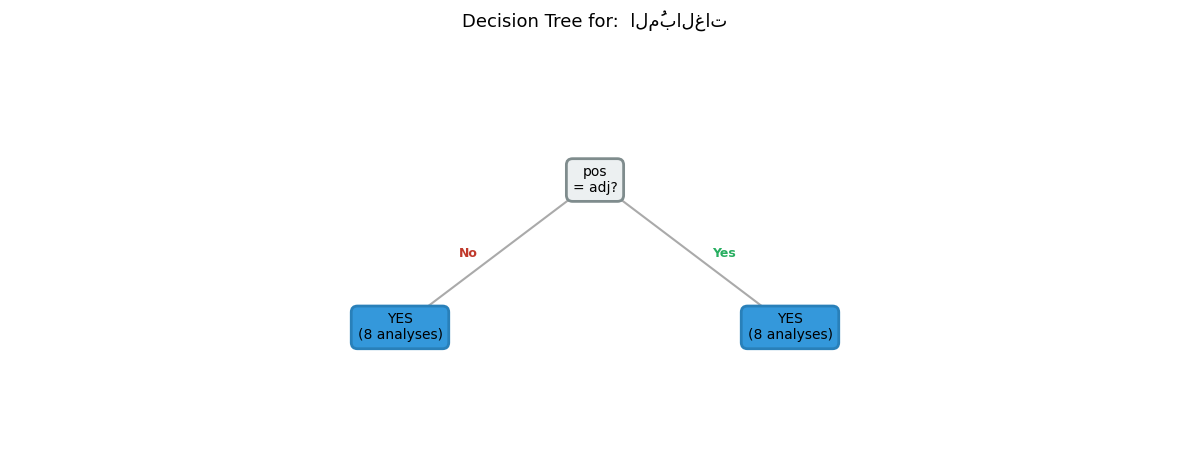

In [46]:
import matplotlib.pyplot as plt

def draw_node_tree(tree, word):

    def subtree_width(node):
        if node.pred is not None: return 1
        return subtree_width(node.left) + subtree_width(node.right)

    pos_map = {}
    def layout(node, depth, x0, x1):
        if node.pred is not None:
            pos_map[id(node)] = ((x0 + x1) / 2, -depth)
            return
        lw = subtree_width(node.left)
        rw = subtree_width(node.right)
        split = x0 + (x1 - x0) * lw / (lw + rw)
        pos_map[id(node)] = ((x0 + x1) / 2, -depth)
        layout(node.left,  depth + 1, x0, split)
        layout(node.right, depth + 1, split, x1)

    total = subtree_width(tree)
    layout(tree, 0, 0, total)
    min_y = min(y for _, y in pos_map.values())

    fig, ax = plt.subplots(figsize=(max(12, total * 2.8), abs(min_y) * 2.8 + 2))
    ax.set_xlim(-0.5, total + 0.5)
    ax.set_ylim(min_y - 0.9, 0.9)
    ax.axis('off')

    def draw_edges(node):
        if node.pred is not None: return
        x, y = pos_map[id(node)]
        xl, yl = pos_map[id(node.left)]
        xr, yr = pos_map[id(node.right)]
        ax.plot([x, xl], [y, yl], color='#aaa', lw=1.5, zorder=0)
        ax.plot([x, xr], [y, yr], color='#aaa', lw=1.5, zorder=0)
        ax.text((x+xl)/2 - 0.05, (y+yl)/2, 'No',  fontsize=9, color='#C0392B',
                ha='right', va='center', fontweight='bold')
        ax.text((x+xr)/2 + 0.05, (y+yr)/2, 'Yes', fontsize=9, color='#27AE60',
                ha='left',  va='center', fontweight='bold')
        draw_edges(node.left)
        draw_edges(node.right)

    def draw_nodes(node):
        x, y = pos_map[id(node)]
        if node.pred is not None:
            label = f"{node.pred}\n({node.n} {'analysis' if node.n == 1 else 'analyses'})"
            fc = '#3498DB' if node.pred == 'YES' else '#E67E22'
            ec = '#2980B9' if node.pred == 'YES' else '#D35400'
        else:
            feat, val = node.feature.split('_', 1)
            label = f"{feat}\n= {val}?"
            fc, ec = '#ECF0F1', '#7F8C8D'
        ax.text(x, y, label, ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.45', facecolor=fc, edgecolor=ec, lw=2),
                zorder=1)
        if node.pred is None:
            draw_nodes(node.left)
            draw_nodes(node.right)

    draw_edges(tree)
    draw_nodes(tree)
    plt.title(f"Decision Tree for:  {word}", fontsize=13, pad=15)
    plt.tight_layout()
    plt.show()

draw_node_tree(tree, word)

=== Free tree (no pos priority) ===
=> NO  (16 analyses)


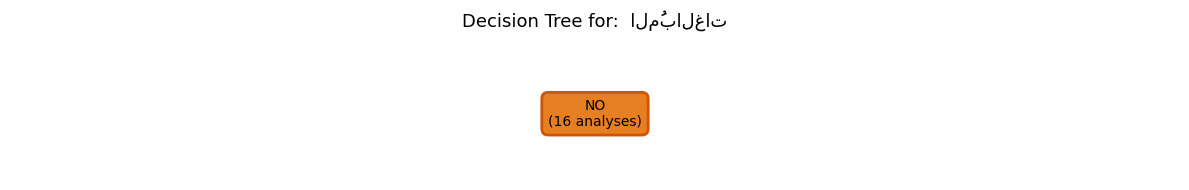

In [47]:
# Tree without pos prioritization — algorithm picks the best feature freely
clf_free = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_free.fit(X, y)

free_tree = sklearn_to_node(clf_free, list(X.columns))

print("=== Free tree (no pos priority) ===")
print_node(free_tree)

draw_node_tree(free_tree, word)

## Summary
Which feature values separate YES from NO analyses?

In [48]:
yes_df = df[df['label'] == 1]
no_df  = df[df['label'] == 0]

print("=== YES analyses ===")
feats =['diac', 'pos', 'vox', 'mod', 'gen', 'asp', 'num', 'stt', 'cas', 'rat', 'prc0', 'prc1', 'prc2', 'prc3', 'per', 'enc0', 'stemcat', 'pattern']
print(yes_df[feats].to_string(index=False))
print()
print("=== NO analyses ===")
print(no_df[feats].to_string(index=False))
print()
print("=== Feature values unique to YES or NO ===")
for feat in  feats:
    yes_vals = set(yes_df[feat].unique())
    no_vals  = set(no_df[feat].unique())
    only_yes = yes_vals - no_vals
    only_no  = no_vals - yes_vals
    if only_yes or only_no:
        print(f"  {feat}: only_YES={only_yes}  only_NO={only_no}")


=== YES analyses ===
        diac  pos vox mod gen asp num stt cas rat   prc0 prc1 prc2 prc3 per enc0 stemcat      pattern
 المُبالَغات noun  na  na   f  na   p   d   u   i Al_det    0    0    0  na    0   NapAt  المُ1ا2َ3ات
 المُبالَغات noun  na  na   f  na   p   c   u   i Al_det    0    0    0  na    0   NapAt  المُ1ا2َ3ات
المُبالَغاتُ noun  na  na   f  na   p   c   n   i Al_det    0    0    0  na    0   NapAt المُ1ا2َ3اتُ
المُبالَغاتُ noun  na  na   f  na   p   d   n   i Al_det    0    0    0  na    0   NapAt المُ1ا2َ3اتُ
المُبالَغاتِ noun  na  na   f  na   p   c   a   i Al_det    0    0    0  na    0   NapAt المُ1ا2َ3اتِ
المُبالَغاتِ noun  na  na   f  na   p   d   a   i Al_det    0    0    0  na    0   NapAt المُ1ا2َ3اتِ
المُبالَغاتِ noun  na  na   f  na   p   c   g   i Al_det    0    0    0  na    0   NapAt المُ1ا2َ3اتِ
المُبالَغاتِ noun  na  na   f  na   p   d   g   i Al_det    0    0    0  na    0   NapAt المُ1ا2َ3اتِ
 المُبالِغات  adj  na  na   f  na   p   d   u   n Al_det    0

In [49]:
"""
Diacritic Feature Elimination Analyzer
=======================================
Given a list of CAMEL morphological analyses and a target diacritized word,
computes what each diacritic position locks in, eliminates, or leaves open.

Usage:
    python diacritic_elimination.py

Customize `ANALYSES` and `TARGET` at the bottom.
"""

from dataclasses import dataclass, field
from typing import Optional
import unicodedata

# ── Arabic diacritic Unicode codepoints ────────────────────────────────────
FATHA   = 'َ'  # َ
KASRA   = 'ِ'  # ِ
DAMMA   = 'ُ'  # ُ
SUKUN   = 'ْ'  # ْ
SHADDA  = 'ّ'  # ّ
TANWIN_D = 'ً' # ً  fathatan
TANWIN_N = 'ٌ' # ٌ  dammatan
TANWIN_G = 'ٍ' # ٍ  kasratan

DIACRITICS = {FATHA, KASRA, DAMMA, SUKUN, SHADDA, TANWIN_D, TANWIN_N, TANWIN_G}

DIAC_NAME = {
    FATHA:    'fatha (َ)',
    KASRA:    'kasra (ِ)',
    DAMMA:    'damma (ُ)',
    SUKUN:    'sukun (ْ)',
    SHADDA:   'shadda (ّ)',
    TANWIN_D: 'fathatan (ً)',
    TANWIN_N: 'dammatan (ٌ)',
    TANWIN_G: 'kasratan (ٍ)',
}

# Features we track from CAMEL analyses
# FEATURES = ['pos', 'lex', 'pattern', 'vox', 'cas', 'stt', 'rat', 'per', 'asp', 'num', 'gen']


# ── Helpers ────────────────────────────────────────────────────────────────

def strip_diacritics(text: str) -> str:
    """Remove all Arabic diacritics from a string."""
    return ''.join(c for c in text if c not in DIACRITICS)


def extract_diacritics(text: str) -> list[tuple[int, str]]:
    """
    Return list of (consonant_position, diacritic) pairs.
    consonant_position = index among base consonants only (0-based).
    A shadda that precedes a vowel is attached to the same consonant.
    """
    result = []
    con_idx = -1
    pending_shadda = False
    for ch in text:
        if ch not in DIACRITICS:
            con_idx += 1
            pending_shadda = False
        elif ch == SHADDA:
            pending_shadda = True
            result.append((con_idx, ch))
        else:
            result.append((con_idx, ch))
    return result


def apply_n_diacritics(diacritized: str, n: int) -> str:
    """
    Return the word with only the first n diacritics visible,
    the rest stripped — simulating partial diacritization.
    """
    result = []
    seen = 0
    for ch in diacritized:
        if ch in DIACRITICS:
            if seen < n:
                result.append(ch)
                seen += 1
            # else skip
        else:
            result.append(ch)
    return ''.join(result)


def count_diacritics(text: str) -> int:
    return sum(1 for c in text if c in DIACRITICS)


def feature_values(analyses: list[dict], feat: str) -> set:
    return {a.get(feat, 'na') for a in analyses}


def describe_feature_change(before: set, after: set, feat: str) -> dict:
    """
    Classify what happened to a feature across a disambiguation step.
    Returns a status and a description string.
    """
    eliminated = before - after
    remaining  = after

    if len(after) == 1 and len(before) > 1:
        val = next(iter(after))
        return {
            'status': 'locked',
            'before': before,
            'after':  after,
            'note':   f"locked → {val}"
        }
    elif len(after) == 1 and len(before) == 1:
        val = next(iter(after))
        return {
            'status': 'locked',
            'before': before,
            'after':  after,
            'note':   f"already determined: {val}"
        }
    elif eliminated:
        return {
            'status': 'narrowing',
            'before': before,
            'after':  after,
            'note':   f"eliminated {{{', '.join(sorted(str(v) for v in eliminated))}}} → still open: {{{', '.join(sorted(str(v) for v in after))}}}"
        }
    else:
        return {
            'status': 'open',
            'before': before,
            'after':  after,
            'note':   f"unchanged: {{{', '.join(sorted(str(v) for v in after))}}}"
        }


# ── Core analyzer ──────────────────────────────────────────────────────────

@dataclass
class Stage:
    label: str
    partial_form: str
    n_diacritics_applied: int
    diacritic_added: Optional[str]
    diacritic_position: Optional[int]
    analyses: list[dict]
    feature_states: dict = field(default_factory=dict)


def analyze(target_diacritized: str, all_analyses: list[dict]) -> list[Stage]:
    base = strip_diacritics(target_diacritized)
    diacs = extract_diacritics(target_diacritized)
    n_total = len(diacs)

    stages: list[Stage] = []
    prev_analyses = all_analyses
    prev_feat_vals = {f: feature_values(all_analyses, f) for f in FEATURES}

    s0 = Stage(
        label="No diacritics",
        partial_form=base,
        n_diacritics_applied=0,
        diacritic_added=None,
        diacritic_position=None,
        analyses=all_analyses,
        feature_states={
            f: {'status': 'open', 'before': set(), 'after': prev_feat_vals[f],
                'note': f"open: {{{', '.join(sorted(str(v) for v in prev_feat_vals[f]))}}}"}
            for f in FEATURES
        }
    )
    stages.append(s0)

    for i in range(1, n_total + 1):
        partial = apply_n_diacritics(target_diacritized, i)
        con_pos, diac_char = diacs[i - 1]

        surviving = [
            a for a in all_analyses
            if _is_consistent(a.get('diac', ''), partial)
        ]

        curr_feat_vals = {f: feature_values(surviving, f) for f in FEATURES}

        feat_states = {}
        for f in FEATURES:
            feat_states[f] = describe_feature_change(
                prev_feat_vals[f], curr_feat_vals[f], f
            )

        stage = Stage(
            label=f"After diacritic {i} — {DIAC_NAME.get(diac_char, diac_char)} on consonant {con_pos + 1}",
            partial_form=partial,
            n_diacritics_applied=i,
            diacritic_added=diac_char,
            diacritic_position=con_pos,
            analyses=surviving,
            feature_states=feat_states,
        )
        stages.append(stage)

        prev_feat_vals = curr_feat_vals
        prev_analyses = surviving

    return stages


def _is_consistent(candidate_diac: str, partial: str) -> bool:
    """
    Check whether `candidate_diac` is consistent with `partial`.

    1. Same base consonants.
    2. For every consonant position that has diacritics in `partial`,
       those diacritics must be a SUBSET of the candidate's diacritics
       at that position — allowing the candidate to have additional
       diacritics (e.g. a vowel accompanying a shadda).
    """
    if strip_diacritics(candidate_diac) != strip_diacritics(partial):
        return False

    partial_diacs = extract_diacritics(partial)
    cand_diacs    = extract_diacritics(candidate_diac)

    from collections import defaultdict
    partial_by_pos: dict[int, set] = defaultdict(set)
    cand_by_pos:    dict[int, set] = defaultdict(set)

    for pos, d in partial_diacs:
        partial_by_pos[pos].add(d)
    for pos, d in cand_diacs:
        cand_by_pos[pos].add(d)

    # Input diacritics must be a SUBSET of the analysis diacritics at each position
    # e.g. input {ّ} ⊆ analysis {َ, ّ} → consistent
    for pos, diacs in partial_by_pos.items():
        if not diacs.issubset(cand_by_pos[pos]):
            return False

    return True


# ── Pretty printer ─────────────────────────────────────────────────────────

STATUS_ICON = {
    'locked':   '✓ LOCKED  ',
    'narrowing':'↓ NARROWED',
    'open':     '· open    ',
}

def print_report(target: str, stages: list[Stage]):
    sep = '─' * 72
    print(sep)
    print(f"  Diacritic Feature Elimination — target: {target}")
    print(sep)

    for stage in stages:
        print(f"\n{'━'*72}")
        print(f"  STAGE {stage.n_diacritics_applied}  |  {stage.label}")
        print(f"  Form: {stage.partial_form}   |   {len(stage.analyses)} surviving analyses")
        print(f"{'━'*72}")

        for feat in FEATURES:
            fs = stage.feature_states[feat]
            icon = STATUS_ICON.get(fs['status'], '  ')
            print(f"  {icon}  {feat:<10}  {fs['note']}")

        if stage.analyses:
            lex_pos = sorted({
                f"{a.get('lex','?')} ({a.get('pos','?')})"
                for a in stage.analyses
            })
            print(f"\n  Surviving forms: {', '.join(lex_pos)}")

    print(f"\n{'─'*72}")
    print("  Summary of eliminations per diacritic step")
    print(f"{'─'*72}")
    for i, stage in enumerate(stages[1:], 1):
        prev = stages[i - 1]
        eliminated = len(prev.analyses) - len(stage.analyses)
        print(f"  Diacritic {i} ({DIAC_NAME.get(stage.diacritic_added, '?'):20s}) : "
              f"{len(prev.analyses):3d} → {len(stage.analyses):3d}  "
              f"(−{eliminated} analyses)")
    print()


# ── Entry point ────────────────────────────────────────────────────────────

if __name__ == '__main__':

    ANALYSES = alls
    TARGET = word

    stages = analyze(TARGET, ANALYSES)
    print_report(TARGET, stages)

────────────────────────────────────────────────────────────────────────
  Diacritic Feature Elimination — target: المُبالغات
────────────────────────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  STAGE 0  |  No diacritics
  Form: المبالغات   |   16 surviving analyses
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  · open      pos         open: {adj, noun}
  · open      vox         open: {na}
  · open      mod         open: {na}
  · open      gen         open: {f}
  · open      asp         open: {na}
  · open      num         open: {p}
  · open      stt         open: {c, d}
  · open      cas         open: {a, g, n, u}
  · open      rat         open: {i, n}
  · open      prc0        open: {Al_det}
  · open      prc1        open: {0}
  · open      prc2        open: {0}
  · open      prc3        open: {0}
  · open      per         open: {na}
  · open      enc0        open: {0}
  · open